# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Black hole spin (`a`)**  
- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
const MODEL = "analytic"
const MBH = 4.063e6
const SLOW_LIGHT = false
include("../src/main.jl")

Using model: analytic, change src/set_globals.jl to modify.


main (generic function with 1 method)

### Analytic Parameters

In this cell we define the main parameters for the analytic model, including the observer position and screen setup, black hole spin, integration ranges, and observing frequency.  

These are the parameters used in the paper

In [2]:
#Analytic parameters
#Setting up the parameters

#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 30.0
const DYsize = 30.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source in parsecs
const SourceD = 7.778e3 * PC
const bhspin = 0.9
const Rout = 1000.0
const Rstop = 10000.0
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)

# Frequency observed by the camera in Hz
const freq = 230e9

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0


0.0

In [4]:
const metric = METRIC_MKS
const params = GlobalParams(bhspin, Rout, cstartx, cstopx, metric);

In [5]:


using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

const DX = DXsize
const DY = DYsize
#const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)
const total_pixels = pixels_x * pixels_y

# Pre-allocate output arrays
dI_dθo_arr = Matrix{Float64}(undef, pixels_x, pixels_y)
dI_da_arr = Matrix{Float64}(undef, pixels_x, pixels_y)
I_arr = Matrix{Float64}(undef, pixels_x, pixels_y)

#Number of maximum steps in the geodesic calculation
const maxnstep = 15000

#Number of threads used in the calculation
const nthreads = Threads.nthreads()
#Allocating the vector that will keep track of the position of each photon
thread_trajs = [sizehint!(Vector{OfTraj}(), maxnstep) for _ in 1:nthreads+1]

# Progress tracking with chunk-based updates
const CHUNK_SIZE = 100  # Update every 100 pixels
progress_counter = Threads.Atomic{Int}(0)
p = Progress(total_pixels; 
             desc="Computing Image and Sensitivity...", 
             showspeed=true, 
             barlen=30)

# Flatten loop for better load balancing
Threads.@threads :static for idx in 1:total_pixels
    tid = Threads.threadid()
    
    # Convert flat index to (i, j)
    i = (idx - 1) ÷ pixels_x
    j = (idx - 1) % pixels_y

    empty!(thread_trajs[tid])
    # Compute
    dI_dθo_out = Ref{Float64}(0.0)
    intensity_out = Ref{Float64}(0.0)
    dI_da_out = Ref{Float64}(0.0)
    
    AutoDiffGeoTrajEulerMethod!(
        thread_trajs[tid], dI_dθo_out, intensity_out, dI_da_out,
        ro, th, phi, params.a, pixels_x, pixels_y, maxnstep, i, j, 
        freq, fovx, fovy, params.Rout, Rstop
    )
    
    # Store results
    dI_da_arr[i + 1, j + 1] = dI_da_out[]
    dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
    I_arr[i + 1, j + 1] = intensity_out[]
    
    # Update progress every CHUNK_SIZE pixels
    if idx % CHUNK_SIZE == 0
        count = Threads.atomic_add!(progress_counter, CHUNK_SIZE)
        ProgressMeter.update!(p, count)
    end
end

# Final update to ensure we reach 100%
final_count = Threads.atomic_add!(progress_counter, 0)  # Read current value
if final_count < total_pixels
    ProgressMeter.update!(p, total_pixels)
end

finish!(p)

Computing Image and Sensitivity... 100%|██████████████████████████████| Time: 0:00:30 ( 1.87 ms/it)


Plotting the image and the derivatives with proper angular spacing

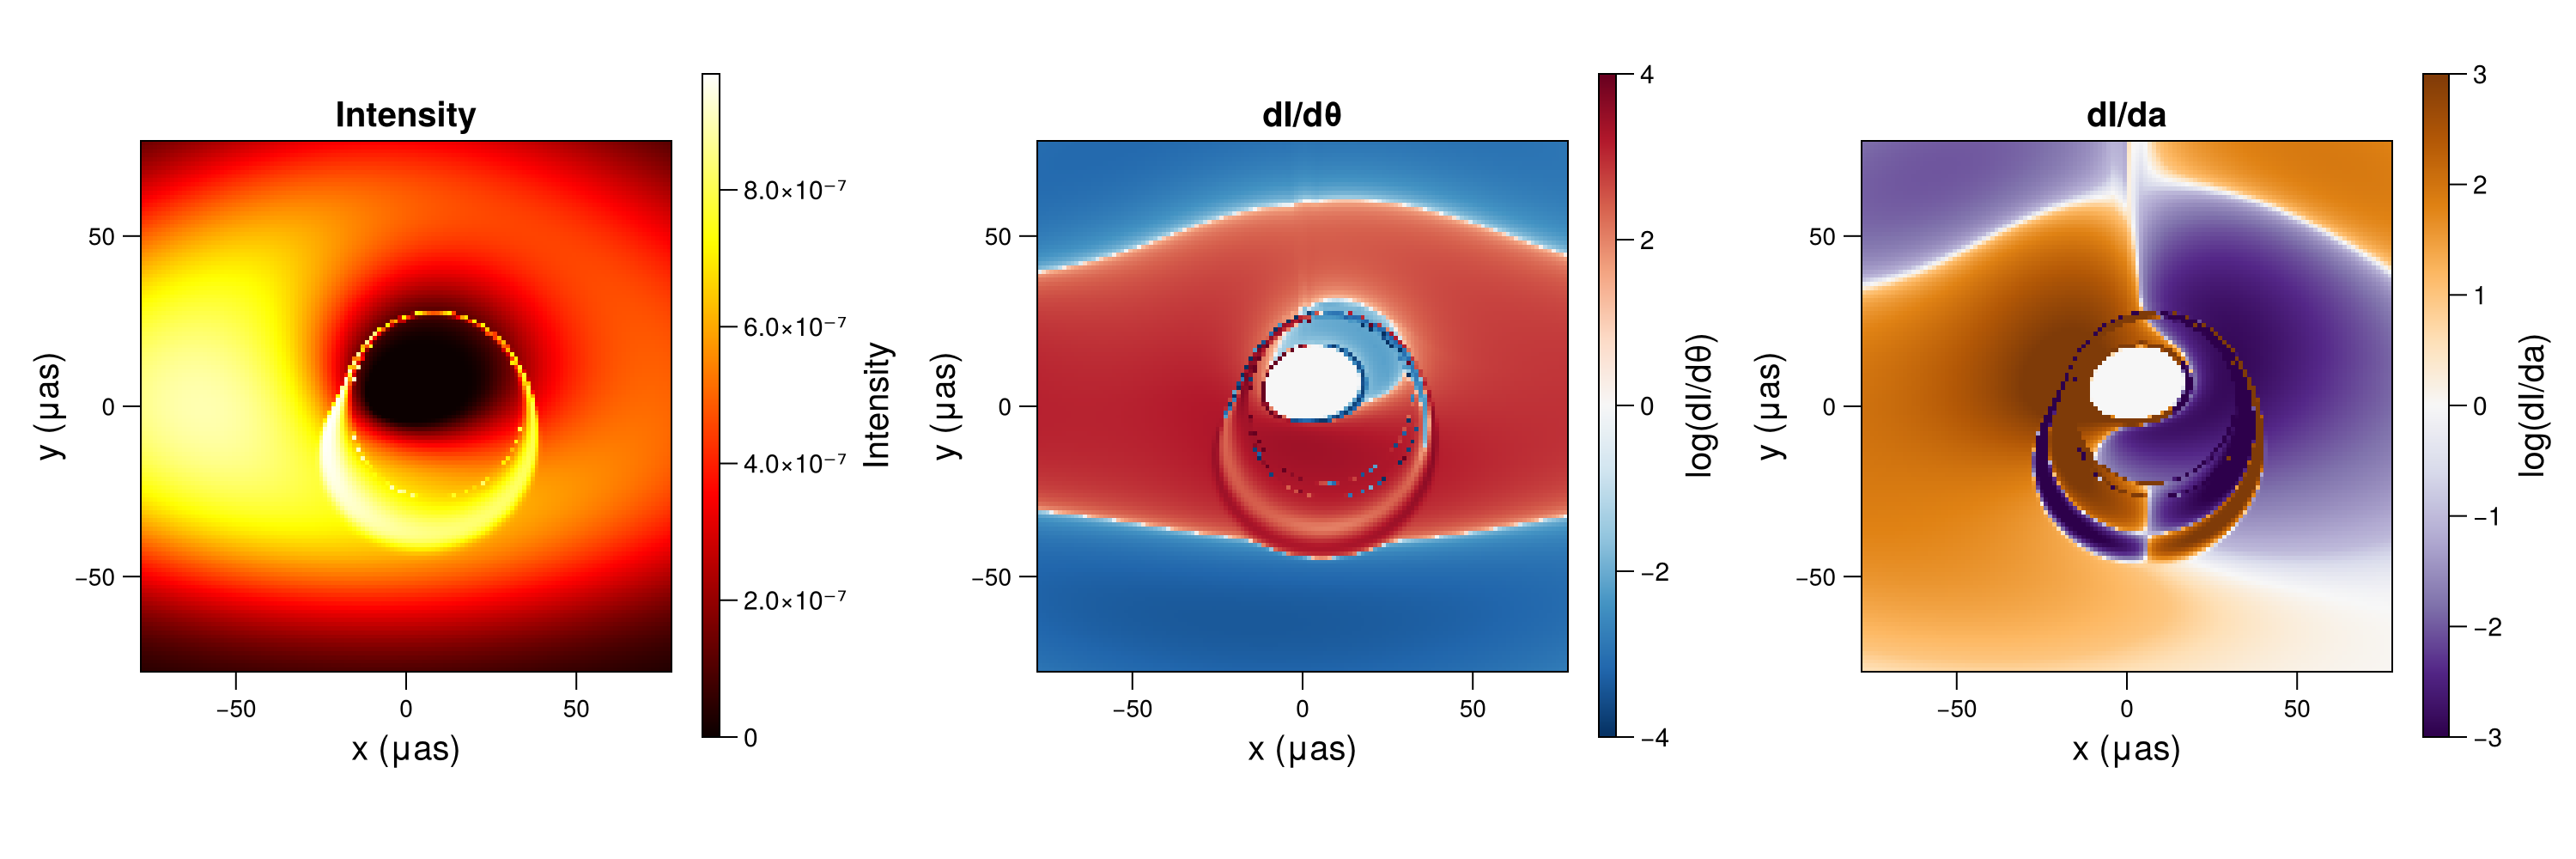

In [7]:
using CairoMakie

d_kpc = 7.78
d_cm = d_kpc * 3.086e21
fov_rg = fovx * ro
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

x_coords = range(-theta_μas, theta_μas, length=pixels_x)
y_coords = range(-theta_μas, theta_μas, length=pixels_y)

function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

axis_tick_size = 14
colorbar_tick_size = 15
colorbar_label_size = 20

vmin_theta = -1e-7
vmax_theta =  1e-7
linthresh_theta = 1e-3 * vmax_theta

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh_theta)
cr_symlog_theta = (
    -(1 + log10(abs(vmin_theta) / linthresh_theta)),
     (1 + log10(abs(vmax_theta) / linthresh_theta))
)

max_val_R = maximum(abs.(filter(!isnan, dI_da_arr))) 

if max_val_R == 0; max_val_R = 1.0; end 

vmin_R = -1e-7
vmax_R =  1e-7
linthresh_R = 1e-2 * vmax_R 

dI_dR_symlog = symlog(dI_da_arr; linthresh=linthresh_R)
cr_symlog_R = (
    -(1 + log10(abs(vmin_R) / linthresh_R)),
     (1 + log10(abs(vmax_R) / linthresh_R))
)

fig = Figure(size = (1500, 500)) 

ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr; colormap = :hot)
cb1 = Colorbar(fig[1, 2], hm1; 
    label = "Intensity",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                    
    width = 10                         
)

ax2 = Axis(fig[1, 3],
    title = "dI/dθ",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog_theta
)
cb2 = Colorbar(fig[1, 4], hm2; 
    label = "log(dI/dθ)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size,
    ticksize = 10,                     
    width = 10                        
)
ax3 = Axis(fig[1, 5],
    title = "dI/da",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm3 = heatmap!(ax3, x_coords, y_coords, dI_dR_symlog;
    colormap = Reverse(:PuOr), 
    colorrange = cr_symlog_R
)

cb3 = Colorbar(fig[1, 6], hm3; 
    label = "log(dI/da)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                     
    width = 15                        
)

fig 